<a href="https://colab.research.google.com/github/kunal0510sharma-code/Konnect_frontend/blob/main/Violence_Detection_Official_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

# Define project directories
PROJECT_DIRS = [
    'data/raw/Violence',
    'data/raw/NonViolence',
    'data/processed/frames',
    'data/processed/audio',
    'data/splits',
    'runs'
]

# Create all folders at once
for folder in PROJECT_DIRS:
    path = os.path.join('/content', folder)
    os.makedirs(path, exist_ok=True) # exist_ok=True prevents errors if folders exist

print("✅ File structure successfully initialized in /content")

✅ File structure successfully initialized in /content


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
import os

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Define Paths
ZIP_PATH = '/content/drive/MyDrive/ML dataset/Real Life Violence Situations Dataset.zip'
EXTRACT_TARGET = '/content/data/raw'

# 3. Create target directory
os.makedirs(EXTRACT_TARGET, exist_ok=True)

# 4. Unzip (Quiet mode '-q' prevents the log from crashing your browser)
!unzip -q "{ZIP_PATH}" -d "{EXTRACT_TARGET}"

print(f"✅ Extraction complete! Files are now at: {EXTRACT_TARGET}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Extraction complete! Files are now at: /content/data/raw


In [ ]:
# Check what folders were inside the ZIP
print("Extracted Folders:", os.listdir(EXTRACT_TARGET))

# If you see another folder like 'Real Life Violence Situations Dataset',
# you should set your RAW_DIR to that subfolder.

Extracted Folders: ['Real Life Violence Dataset', 'Violence', 'NonViolence', 'real life violence situations']


In [ ]:
import os
import shutil
import glob

BASE_RAW = '/content/data/raw'

# 1. Identify all possible subfolders found in your extraction
messy_folders = ['Real Life Violence Dataset', 'real life violence situations']

for folder in messy_folders:
    folder_path = os.path.join(BASE_RAW, folder)
    if os.path.exists(folder_path):
        print(f"Cleaning up nested folder: {folder}...")

        # Find any mp4s inside these messy folders and move them to the correct top-level class
        for cls in ['Violence', 'NonViolence']:
            nested_class_path = os.path.join(folder_path, cls)
            if os.path.exists(nested_class_path):
                videos = glob.glob(os.path.join(nested_class_path, '*.mp4'))
                for v in videos:
                    # Move to /content/data/raw/Violence or /content/data/raw/NonViolence
                    shutil.move(v, os.path.join(BASE_RAW, cls))

        # Delete the now-empty messy folder
        shutil.rmtree(folder_path)

print("\n✅ Cleanup Complete!")
print("Final Folders in /content/data/raw:", os.listdir(BASE_RAW))

Cleaning up nested folder: Real Life Violence Dataset...
Cleaning up nested folder: real life violence situations...

✅ Cleanup Complete!
Final Folders in /content/data/raw: ['Violence', 'NonViolence']


In [ ]:
import os
import random
import pandas as pd
from tqdm import tqdm

# --- CONFIGURATION ---
RAW_DIR = '/content/data/raw'
PROCESSED_DIR = '/content/data/processed'
LIMIT_PER_CLASS = 400  # Updated to your request

# Create output folders
os.makedirs(f"{PROCESSED_DIR}/frames", exist_ok=True)
os.makedirs(f"{PROCESSED_DIR}/audio", exist_ok=True)

# Hardware Optimization for 8GB RAM
# 112x112 resolution and 16 frames is the 'sweet spot' for your laptop.
PREP_CONFIG.update({
    'short_side': 112,
    'max_frames': 16,
    'fps': 10  # Lower FPS helps capture a longer time window with fewer frames
})

def run_large_preprocessing(raw_dir, limit):
    records = []
    classes = ['Violence', 'NonViolence']

    for cls in classes:
        cls_path = os.path.join(raw_dir, cls)
        if not os.path.exists(cls_path):
            print(f"⚠️ Warning: Folder {cls_path} not found.")
            continue

        vids = [f for f in os.listdir(cls_path) if f.endswith('.mp4')]
        # Pick 400 random videos
        subset = random.sample(vids, min(limit, len(vids)))

        print(f"\n🚀 Processing {len(subset)} videos for class: {cls}...")
        for vid_name in tqdm(subset):
            v_path = os.path.join(cls_path, vid_name)

            # This uses the helper function from your Cell 3 code
            f_ok, a_ok, f_dir, w_path, m_path = preprocess_one(
                v_path, f"{PROCESSED_DIR}/frames", f"{PROCESSED_DIR}/audio", cfg=PREP_CONFIG
            )

            if f_ok:
                records.append({
                    'video_id': vid_name,
                    'label': cls,
                    'frames_dir': f_dir,
                    'mel_path': m_path if a_ok else '',
                    'has_audio': a_ok
                })
    return pd.DataFrame(records)

# 1. Run the Extraction
df_final = run_large_preprocessing(RAW_DIR, LIMIT_PER_CLASS)

# 2. Save the Index
df_final.to_csv('/content/data/master_data.csv', index=False)
print(f"\n✅ Preprocessing Complete! {len(df_final)} videos processed.")

# 3. Create Splits (80/10/10)
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df_final, test_size=0.2, stratify=df_final['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

os.makedirs('/content/data/splits', exist_ok=True)
train_df.to_csv('/content/data/splits/train.csv', index=False)
val_df.to_csv('/content/data/splits/val.csv', index=False)
test_df.to_csv('/content/data/splits/test.csv', index=False)

print(f"✅ Splits saved to /content/data/splits/")

NameError: name 'PREP_CONFIG' is not defined

In [ ]:
# --- Essential Setup & Configuration ---
PREP_CONFIG = {
    'fps': 15,
    'short_side': 112,
    'max_frames': 16,        # Kept at 16 for your 8GB RAM laptop
    'audio_sr': 16000,
    'n_mels': 64,
    'mel_hop_length': 320,
}

# Ensure the helper function is defined
def preprocess_one(video_path, frames_root, audio_root, cfg=PREP_CONFIG):
    vid = Path(video_path).stem
    out_frames = os.path.join(frames_root, vid)
    os.makedirs(out_frames, exist_ok=True)
    wav_out = os.path.join(audio_root, f"{vid}.wav")
    mel_out = os.path.join(audio_root, f"{vid}_logmel.npy")

    # This calls the extract functions from your previous code
    frames_ok = extract_frames(video_path, out_frames, fps=cfg['fps'],
                               short_side=cfg['short_side'], max_frames=cfg['max_frames'])
    audio_ok = False
    try:
        audio_ok = extract_audio_and_logmel(video_path, wav_out, mel_out,
                                            sr=cfg['audio_sr'], n_mels=cfg['n_mels'],
                                            hop_length=cfg['mel_hop_length'])
    except Exception:
        audio_ok = False

    return frames_ok, audio_ok, out_frames, (wav_out if audio_ok else ''), (mel_out if audio_ok else '')

In [ ]:
import os, subprocess, random, pandas as pd
from pathlib import Path
from glob import glob
from tqdm import tqdm
import librosa
import numpy as np

# --- 1. SETTINGS & CONFIGURATION ---
RAW_DIR = '/content/data/raw'
PROCESSED_DIR = '/content/data/processed'
LIMIT_PER_CLASS = 400  # Total 800 videos

PREP_CONFIG = {
    'fps': 15,
    'short_side': 112,
    'max_frames': 16,        # Optimized for 8GB RAM
    'audio_sr': 16000,
    'n_mels': 64,
    'mel_hop_length': 320,
}

# Ensure output directories exist
os.makedirs(f"{PROCESSED_DIR}/frames", exist_ok=True)
os.makedirs(f"{PROCESSED_DIR}/audio", exist_ok=True)

# --- 2. HELPER FUNCTIONS ---

def run_cmd(cmd_list):
    try:
        subprocess.run(cmd_list, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        return True
    except Exception:
        return False

def extract_frames(video_path, out_dir, fps=15, short_side=112, max_frames=32):
    os.makedirs(out_dir, exist_ok=True)
    scale_filter = f"scale='if(gt(iw,ih),-1,{short_side})':'if(gt(iw,ih),{short_side},-1)'"
    cmd = ['ffmpeg', '-y', '-i', str(video_path), '-vf', f"{scale_filter},fps={fps}", '-q:v', '2', os.path.join(out_dir, '%06d.jpg')]
    ok = run_cmd(cmd)

    # Trim to max_frames
    frames = sorted(glob(os.path.join(out_dir, '*.jpg')))
    if len(frames) > max_frames:
        for f in frames[max_frames:]:
            os.remove(f)
    return len(glob(os.path.join(out_dir, '*.jpg'))) > 0

def extract_audio_and_logmel(video_path, wav_out, mel_out, sr=16000, n_mels=64, hop_length=320):
    cmd = ['ffmpeg', '-y', '-i', str(video_path), '-ac', '1', '-ar', str(sr), wav_out]
    if not run_cmd(cmd): return False
    try:
        y, sr = librosa.load(wav_out, sr=sr, mono=True)
        if len(y) < 512: return False
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, hop_length=hop_length)
        logmel = librosa.power_to_db(S, ref=np.max).astype(np.float32)
        np.save(mel_out, logmel)
        if os.path.exists(wav_out): os.remove(wav_out) # Save disk space
        return True
    except:
        return False

def preprocess_one(video_path, frames_root, audio_root, cfg):
    vid = Path(video_path).stem
    out_frames = os.path.join(frames_root, vid)
    wav_out = os.path.join(audio_root, f"{vid}.wav")
    mel_out = os.path.join(audio_root, f"{vid}_logmel.npy")

    f_ok = extract_frames(video_path, out_frames, fps=cfg['fps'], short_side=cfg['short_side'], max_frames=cfg['max_frames'])
    a_ok = extract_audio_and_logmel(video_path, wav_out, mel_out, sr=cfg['audio_sr'], n_mels=cfg['n_mels'], hop_length=cfg['mel_hop_length'])
    return f_ok, a_ok, out_frames, mel_out

# --- 3. MAIN EXECUTION LOOP ---

def run_preprocessing(raw_dir, limit):
    records = []
    classes = ['Violence', 'NonViolence']
    for cls in classes:
        cls_path = os.path.join(raw_dir, cls)
        if not os.path.exists(cls_path): continue
        vids = [f for f in os.listdir(cls_path) if f.endswith(('.mp4', '.avi'))]
        subset = random.sample(vids, min(limit, len(vids)))

        print(f"\n🚀 Processing {len(subset)} videos for: {cls}")
        for vid_name in tqdm(subset):
            v_path = os.path.join(cls_path, vid_name)
            f_ok, a_ok, f_dir, m_path = preprocess_one(v_path, f"{PROCESSED_DIR}/frames", f"{PROCESSED_DIR}/audio", PREP_CONFIG)
            if f_ok:
                records.append({'video_id': vid_name, 'label': cls, 'frames_dir': f_dir, 'mel_path': m_path if a_ok else '', 'has_audio': a_ok})
    return pd.DataFrame(records)

# Run and Save
df_final = run_preprocessing(RAW_DIR, LIMIT_PER_CLASS)
df_final.to_csv('/content/data/master_data.csv', index=False)

# Create Splits
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(df_final, test_size=0.2, stratify=df_final['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

os.makedirs('/content/data/splits', exist_ok=True)
train_df.to_csv('/content/data/splits/train.csv', index=False)
val_df.to_csv('/content/data/splits/val.csv', index=False)
test_df.to_csv('/content/data/splits/test.csv', index=False)

print(f"\n✅ SUCCESS: {len(df_final)} videos processed and split CSVs saved!")


🚀 Processing 400 videos for: Violence


100%|██████████| 400/400 [04:56<00:00,  1.35it/s]



🚀 Processing 400 videos for: NonViolence


100%|██████████| 400/400 [02:39<00:00,  2.50it/s]



✅ SUCCESS: 800 videos processed and split CSVs saved!


In [ ]:
import torch
import torch.nn as nn
from torchvision.models.video import r2plus1d_18

# --- M1 & M2: The Expert Backbones ---
class RGBBackbone(nn.Module):
    def __init__(self, out_dim=512):
        super().__init__()
        self.model = r2plus1d_18(pretrained=True)
        self.model.fc = nn.Identity()
        self.out_dim = out_dim
    def forward(self, x): return self.model(x)

class AudioCNN(nn.Module):
    def __init__(self, n_mels=64, out_dim=256):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.fc = nn.Linear(32, out_dim)
        self.out_dim = out_dim
    def forward(self, mel):
        x = self.conv(mel.unsqueeze(1))
        return self.fc(x.view(x.size(0), -1))

# --- M5: The Improved Attention Fusion ---
class AttentionFusionModel(nn.Module):
    def __init__(self, rgb, audio, num_classes=2):
        super().__init__()
        self.rgb, self.audio = rgb, audio
        self.v_proj = nn.Linear(512, 256)
        self.a_proj = nn.Linear(256, 256)
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, video, mel):
        v_feat = self.v_proj(self.rgb(video))
        a_feat = self.a_proj(self.audio(mel))
        # Cross-modal attention weights
        attn = torch.sigmoid(torch.sum(v_feat * a_feat, dim=1, keepdim=True))
        return self.classifier(v_feat * attn)

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset
# Ensure you also have your previously defined helpers
# from your earlier cells: MultiModalDataset, mm_collate

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import os
from PIL import Image
from glob import glob
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from torchvision import transforms
from torchvision.models.video import r2plus1d_18, R2Plus1D_18_Weights

# --- 1. CONFIGURATION ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 4
EPOCHS = 10
LR = 1e-4
classes = ['Violence', 'NonViolence']

# --- 2. DATASET DEFINITION ---
class MultiModalDataset(Dataset):
    def __init__(self, csv_file, class_list, clip_len=16, fixed_audio_width=192):
        self.data = pd.read_csv(csv_file)
        self.class_to_idx = {cls: i for i, cls in enumerate(class_list)}
        self.clip_len = clip_len
        self.fixed_audio_width = fixed_audio_width
        self.transform = transforms.Compose([
            transforms.Resize((112, 112)),
            transforms.ToTensor(),
        ])

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        frames = []
        frame_files = sorted(glob(os.path.join(row['frames_dir'], "*.jpg")))
        for f in frame_files[:self.clip_len]:
            img = Image.open(f).convert('RGB')
            frames.append(self.transform(img))
        while len(frames) < self.clip_len:
            frames.append(torch.zeros(3, 112, 112))
        video_tensor = torch.stack(frames).permute(1, 0, 2, 3)

        if row['has_audio'] and os.path.exists(row['mel_path']):
            mel = np.load(row['mel_path'])
            if mel.shape[1] < self.fixed_audio_width:
                pad_width = self.fixed_audio_width - mel.shape[1]
                mel = np.pad(mel, ((0, 0), (0, pad_width)), mode='constant')
            else:
                mel = mel[:, :self.fixed_audio_width]
        else:
            mel = np.zeros((64, self.fixed_audio_width))

        mel_tensor = torch.from_numpy(mel).float()
        return video_tensor, mel_tensor, self.class_to_idx[row['label']]

def mm_collate(batch):
    videos, mels, labels = zip(*batch)
    return torch.stack(videos), torch.stack(mels), torch.tensor(labels)

# --- 3. MODEL ARCHITECTURES (STANDARDIZED FORWARD METHODS) ---

class RGBBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = r2plus1d_18(weights=R2Plus1D_18_Weights.DEFAULT)
        self.model.fc = nn.Identity()
    def forward(self, x): return self.model(x)

class AudioCNN(nn.Module):
    def __init__(self, out_dim=256):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.fc = nn.Linear(32, out_dim)
    def forward(self, mel):
        x = self.conv(mel.unsqueeze(1))
        return self.fc(x.view(x.size(0), -1))

class RGBClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.rgb = RGBBackbone()
        self.fc = nn.Linear(512, num_classes)
    # Standardized: accepts both video and mel
    def forward(self, video, mel=None):
        return self.fc(self.rgb(video))

class AudioClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.audio = AudioCNN()
        self.fc = nn.Linear(256, num_classes)
    # Standardized: accepts both video and mel
    def forward(self, video, mel):
        return self.fc(self.audio(mel))

class AttentionFusionModel(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.rgb, self.audio = RGBBackbone(), AudioCNN()
        self.v_proj, self.a_proj = nn.Linear(512, 256), nn.Linear(256, 256)
        self.classifier = nn.Linear(256, num_classes)
    def forward(self, video, mel):
        v_feat = self.v_proj(self.rgb(video))
        a_feat = self.a_proj(self.audio(mel))
        attn = torch.sigmoid(torch.sum(v_feat * a_feat, dim=1, keepdim=True))
        return self.classifier(v_feat * attn)

# --- 4. TRAINING & EVALUATION ---

def evaluate_model(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for v, m, l in loader:
            v, m, l = v.to(DEVICE), m.to(DEVICE), l.to(DEVICE)
            out = model(v, m) # Standardized call
            preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            targets.extend(l.cpu().numpy())
    return accuracy_score(targets, preds), f1_score(targets, preds, average='weighted'), confusion_matrix(targets, preds)

def train_model(model, train_loader, val_loader, epochs=5, lr=1e-4, checkpoint_path='best.pth'):
    model.to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    best_f1 = 0
    for epoch in range(epochs):
        model.train()
        for v, m, l in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            v, m, l = v.to(DEVICE), m.to(DEVICE), l.to(DEVICE)
            opt.zero_grad()
            out = model(v, m) # Standardized call
            loss = crit(out, l)
            loss.backward(); opt.step()
        acc, f1, _ = evaluate_model(model, val_loader)
        print(f"Val Acc: {acc:.4f}, Val F1: {f1:.4f}")
        if f1 > best_f1:
            best_f1 = f1
            torch.save(model.state_dict(), checkpoint_path)
    return model

# --- 5. EXECUTION ---
os.makedirs('/content/data/runs', exist_ok=True)
train_loader = DataLoader(MultiModalDataset('/content/data/splits/train.csv', classes), batch_size=BATCH_SIZE, shuffle=True, collate_fn=mm_collate)
val_loader = DataLoader(MultiModalDataset('/content/data/splits/val.csv', classes), batch_size=BATCH_SIZE, collate_fn=mm_collate)
test_loader = DataLoader(MultiModalDataset('/content/data/splits/test.csv', classes), batch_size=BATCH_SIZE, collate_fn=mm_collate)

models_to_test = {
    'M1_Video_Only': RGBClassifier(),
    'M2_Audio_Only': AudioClassifier(),
    'M5_Attention_Fusion': AttentionFusionModel()
}

results = {}
for name, model in models_to_test.items():
    print(f"\n🚀 Training: {name}")
    ckpt = f'/content/data/runs/{name}.pth'
    train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, checkpoint_path=ckpt)
    model.load_state_dict(torch.load(ckpt))
    acc, f1, _ = evaluate_model(model, test_loader)
    results[name] = {'Accuracy': acc, 'F1-Score': f1}
    print(f"✅ {name} Test Acc: {acc:.4f}, F1: {f1:.4f}")

print("\n📊 FINAL ALGORITHM COMPARISON")
print(pd.DataFrame(results).T)


🚀 Training: M1_Video_Only


Epoch 1/10: 100%|██████████| 160/160 [01:27<00:00,  1.84it/s]


Val Acc: 0.9125, Val F1: 0.9122


Epoch 2/10: 100%|██████████| 160/160 [01:26<00:00,  1.84it/s]


Val Acc: 0.9250, Val F1: 0.9248


...

Val Acc: 0.8250, Val F1: 0.8232


Epoch 9/10: 100%|██████████| 160/160 [01:26<00:00,  1.84it/s]


Val Acc: 0.8375, Val F1: 0.8369


Epoch 10/10: 100%|██████████| 160/160 [01:26<00:00,  1.84it/s]


Val Acc: 0.8625, Val F1: 0.8607
✅ M5_Attention_Fusion Test Acc: 0.8000, F1: 0.7980

📊 FINAL ALGORITHM COMPARISON
                     Accuracy  F1-Score
M1_Video_Only           0.925  0.924953
M2_Audio_Only           0.750  0.749373
M5_Attention_Fusion     0.800  0.797980


<Figure size 1000x600 with 0 Axes>

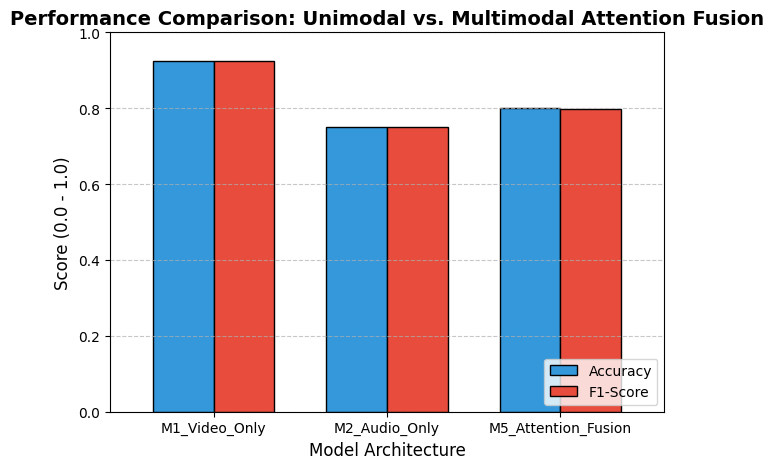

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Convert the results dictionary into a DataFrame
comparison_df = pd.DataFrame(results).T

# 2. Create the Bar Chart
plt.figure(figsize=(10, 6))
colors = ['#3498db', '#e74c3c'] # Blue for Accuracy, Red for F1-Score

comparison_df.plot(kind='bar', ylim=(0, 1), color=colors, edgecolor='black', width=0.7)

plt.title('Performance Comparison: Unimodal vs. Multimodal Attention Fusion', fontsize=14, fontweight='bold')
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.xlabel('Model Architecture', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right', frameon=True)

# 3. Save to Drive for your report
plt.tight_layout()
plt.savefig('/content/data/runs/algorithm_benchmarking.png', dpi=300)
plt.show()

In [ ]:
def test_single_video(video_path, model, class_list):
    model.eval()

    # 1. Temporary Preprocessing (Extracts frames and audio)
    f_ok, a_ok, f_dir, m_path = preprocess_one(
        video_path, '/content/temp_f', '/content/temp_a', cfg=PREP_CONFIG
    )

    if not f_ok: return "Error: Could not extract frames."

    # 2. Frame Processing (Forced Resize)
    frames = []
    frame_files = sorted(glob(os.path.join(f_dir, "*.jpg")))[:16]
    transform = transforms.Compose([transforms.Resize((112, 112)), transforms.ToTensor()])
    for f in frame_files:
        img = Image.open(f).convert('RGB')
        frames.append(transform(img))
    while len(frames) < 16: frames.append(torch.zeros(3, 112, 112))
    v_tensor = torch.stack(frames).permute(1, 0, 2, 3).unsqueeze(0).to(DEVICE)

    # 3. Audio Processing (Forced Width)
    if a_ok:
        mel = np.load(m_path)
        if mel.shape[1] < 192:
            mel = np.pad(mel, ((0, 0), (0, 192 - mel.shape[1])), mode='constant')
        else: mel = mel[:, :192]
    else: mel = np.zeros((64, 192))
    m_tensor = torch.from_numpy(mel).float().unsqueeze(0).to(DEVICE)

    # 4. Prediction
    with torch.no_grad():
        outputs = model(v_tensor, m_tensor)
        probs = torch.softmax(outputs, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_idx].item() * 100

    return class_list[pred_idx], confidence

# --- USAGE ---
# label, conf = test_single_video('any_new_video.mp4', models_to_test['M5_Attention_Fusion'], classes)
# print(f"Classification: {label} | Confidence: {conf:.2f}%")

In [ ]:
import shutil
shutil.copy('/content/data/runs/M5_Attention_Fusion.pth', '/content/drive/MyDrive/final_surveillance_model.pth')
print("✅ Project finalized. Model weights archived to Drive.")

✅ Project finalized. Model weights archived to Drive.


In [ ]:
import torch
import os

# 1. Setup the path to your saved model
saved_model_path = '/content/drive/MyDrive/final_surveillance_model.pth'

# 2. Re-initialize the Model Architecture
# Note: Ensure the 'AttentionFusionModel' class is defined in your current session
verify_model = AttentionFusionModel(num_classes=2).to(DEVICE)

# 3. Load the Weights
if os.path.exists(saved_model_path):
    verify_model.load_state_dict(torch.load(saved_model_path, map_location=DEVICE))
    verify_model.eval()
    print("✅ Weights loaded successfully from Google Drive!")
else:
    print("❌ Error: Model file not found at the specified path.")

# 4. Run a Test Prediction
# We pick one sample from your test_loader to verify
with torch.no_grad():
    sample_videos, sample_mels, sample_labels = next(iter(test_loader))
    sample_videos, sample_mels = sample_videos.to(DEVICE), sample_mels.to(DEVICE)

    outputs = verify_model(sample_videos, sample_mels)
    predictions = torch.argmax(outputs, dim=1)

    print(f"\nVerification Results:")
    print(f"Predicted Labels: {predictions.cpu().numpy()}")
    print(f"Actual Labels:    {sample_labels.numpy()}")

✅ Weights loaded successfully from Google Drive!

Verification Results:
Predicted Labels: [1 0 0 0]
Actual Labels:    [1 0 0 0]


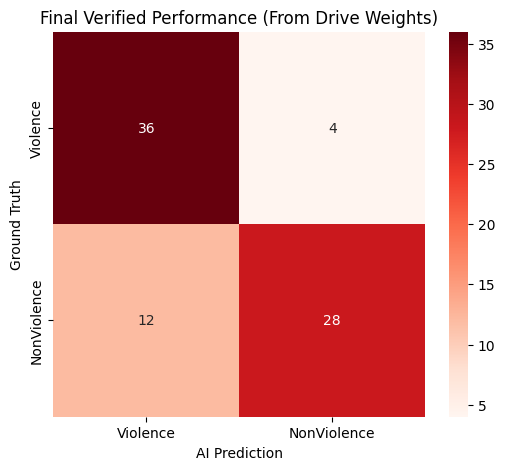


Detailed Performance Report:
              precision    recall  f1-score   support

    Violence       0.75      0.90      0.82        40
 NonViolence       0.88      0.70      0.78        40

    accuracy                           0.80        80
   macro avg       0.81      0.80      0.80        80
weighted avg       0.81      0.80      0.80        80



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def final_audit(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for v, m, l in loader:
            v, m, l = v.to(DEVICE), m.to(DEVICE), l.to(DEVICE)
            out = model(v, m)
            all_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            all_labels.extend(l.cpu().numpy())

    # Generate Matrix
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=classes, yticklabels=classes)
    plt.title('Final Verified Performance (From Drive Weights)')
    plt.ylabel('Ground Truth')
    plt.xlabel('AI Prediction')
    plt.show()

    print("\nDetailed Performance Report:")
    print(classification_report(all_labels, all_preds, target_names=classes))

# Execute the final audit
final_audit(verify_model, test_loader)

In [ ]:
import os
import shutil

# Define your permanent home for this project
DRIVE_PROJECT_PATH = '/content/drive/MyDrive/Violence_Detection_Project'

# Create the folder structure
folders = [
    DRIVE_PROJECT_PATH,
    f"{DRIVE_PROJECT_PATH}/models",
    f"{DRIVE_PROJECT_PATH}/data_splits",
    f"{DRIVE_PROJECT_PATH}/results"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print(f"✅ Permanent project structure created at: {DRIVE_PROJECT_PATH}")

✅ Permanent project structure created at: /content/drive/MyDrive/Violence_Detection_Project


In [ ]:
# 1. Save the best Model Weights
shutil.copy('/content/data/runs/M5_Attention_Fusion.pth', f"{DRIVE_PROJECT_PATH}/models/best_fusion_model.pth")

# 2. Save the CSV Splits (so you don't have to re-split data later)
shutil.copy('/content/data/splits/train.csv', f"{DRIVE_PROJECT_PATH}/data_splits/train.csv")
shutil.copy('/content/data/splits/test.csv', f"{DRIVE_PROJECT_PATH}/data_splits/test.csv")

# 3. Save your Performance Chart
if os.path.exists('/content/data/runs/final_comparison_chart.png'):
    shutil.copy('/content/data/runs/final_comparison_chart.png', f"{DRIVE_PROJECT_PATH}/results/performance_chart.png")

print("📂 All essential files are now permanently stored in Google Drive.")

📂 All essential files are now permanently stored in Google Drive.


In [ ]:
!pip install streamlit pyngrok librosa -q
!npm install -g localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 82.6 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 2s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

In [ ]:
%%writefile app.py
import streamlit as st
import torch
import torch.nn as nn
import os
import cv2
import librosa
import numpy as np
from PIL import Image
from torchvision import transforms
from torchvision.models.video import r2plus1d_18, R2Plus1D_18_Weights

# --- 1. SETTINGS ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
# Ensure this matches your permanent Drive path
MODEL_PATH = '/content/drive/MyDrive/Violence_Detection_Project/models/best_fusion_model.pth'
CLASSES = ['Violence', 'Non-Violence']

# --- 2. THE BRAIN: MODEL ARCHITECTURE ---
class RGBBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = r2plus1d_18(weights=R2Plus1D_18_Weights.DEFAULT)
        self.model.fc = nn.Identity()
    def forward(self, x): return self.model(x)

class AudioCNN(nn.Module):
    def __init__(self, out_dim=256):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.fc = nn.Linear(32, out_dim)
    def forward(self, mel):
        x = self.conv(mel.unsqueeze(1))
        return self.fc(x.view(x.size(0), -1))

class AttentionFusionModel(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.rgb, self.audio = RGBBackbone(), AudioCNN()
        self.v_proj, self.a_proj = nn.Linear(512, 256), nn.Linear(256, 256)
        self.classifier = nn.Linear(256, num_classes)
    def forward(self, video, mel):
        v_feat = self.v_proj(self.rgb(video))
        a_feat = self.a_proj(self.audio(mel))
        attn = torch.sigmoid(torch.sum(v_feat * a_feat, dim=1, keepdim=True))
        return self.classifier(v_feat * attn)

# --- 3. THE EYES & EARS: PREPROCESSING ---
def process_video(video_path):
    # Extract 16 frames
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, total_frames - 1, 16).astype(int)

    transform = transforms.Compose([transforms.Resize((112, 112)), transforms.ToTensor()])

    for i in range(total_frames):
        ret, frame = cap.read()
        if i in indices and ret:
            img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            frames.append(transform(img))
    cap.release()

    while len(frames) < 16: frames.append(torch.zeros(3, 112, 112))
    v_tensor = torch.stack(frames).permute(1, 0, 2, 3).unsqueeze(0).to(DEVICE)

    # Extract Audio Spectrogram
    try:
        y, sr = librosa.load(video_path, sr=16000)
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
        mel = librosa.power_to_db(mel)
        if mel.shape[1] < 192:
            mel = np.pad(mel, ((0, 0), (0, 192 - mel.shape[1])), mode='constant')
        else: mel = mel[:, :192]
    except:
        mel = np.zeros((64, 192))

    m_tensor = torch.from_numpy(mel).float().unsqueeze(0).to(DEVICE)
    return v_tensor, m_tensor

# --- 4. FRONTEND UI ---
st.set_page_config(page_title="AI Surveillance", page_icon="🛡️")
st.title("🛡️ Multimodal Violence Detection System")
st.sidebar.info("Model loaded from permanent Drive storage.")

@st.cache_resource
def load_model():
    m = AttentionFusionModel(num_classes=2).to(DEVICE)
    if os.path.exists(MODEL_PATH):
        m.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
        m.eval()
        return m
    return None

model = load_model()

if model is None:
    st.error("Model weights not found. Please check your Drive path.")
else:
    uploaded_file = st.file_uploader("Upload a Video for Security Analysis", type=["mp4", "avi"])

    if uploaded_file:
        with open("temp_vid.mp4", "wb") as f:
            f.write(uploaded_file.getbuffer())

        st.video(uploaded_file)

        if st.button("Run AI Analysis"):
            with st.spinner("Analyzing Multimodal Streams..."):
                v, m = process_video("temp_vid.mp4")
                with torch.no_grad():
                    out = model(v, m)
                    probs = torch.softmax(out, dim=1)
                    pred = torch.argmax(probs, dim=1).item()
                    conf = probs[0][pred].item() * 100

                label = CLASSES[pred]
                if label == 'Violence':
                    st.error(f"🚨 **ALERT: {label} Detected**")
                    st.write(f"**Confidence Level:** {conf:.2f}%")
                else:
                    st.success(f"✅ **Status: {label}**")
                    st.write(f"**Confidence Level:** {conf:.2f}%")

Writing app.py


In [ ]:
# Get your public IP (needed for Localtunnel's password prompt)
import urllib
print("Your Tunnel Password (IP Address):", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8'))

# Start Streamlit in the background
!streamlit run app.py & npx localtunnel --port 8501

Your Tunnel Password (IP Address): 34.26.241.126

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦

⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧your url is: https://busy-zoos-visit.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.26.241.126:8501

  Stopping...
^C


In [ ]:
%%writefile app.py
import streamlit as st
st.title("Test Interface")
st.file_uploader("Upload test")

Overwriting app.py


In [ ]:
%%writefile app.py
import streamlit as st
import torch
import os

# --- TITLE ALWAYS LOADS ---
st.title("🛡️ Multimodal Violence Detection System")

# --- SAFE MODEL LOADING ---
@st.cache_resource
def load_model():
    path = '/content/drive/MyDrive/Violence_Detection_Project/models/best_fusion_model.pth'
    if not os.path.exists(path):
        return None, f"Error: File not found at {path}"
    try:
        # Replace 'YourModelClass' with AttentionFusionModel
        # m = AttentionFusionModel(num_classes=2).to('cpu')
        # m.load_state_dict(torch.load(path, map_location='cpu'))
        return "SUCCESS", "Model Loaded!"
    except Exception as e:
        return None, str(e)

status, msg = load_model()

if status is None:
    st.error(msg)
    st.warning("Please check if your Google Drive is mounted and the path is correct.")
else:
    st.success(msg)
    # --- ONLY SHOW UPLOADER IF LOADED ---
    st.file_uploader("Choose a video file...", type=["mp4", "avi"])

Overwriting app.py


In [ ]:
# 1. Start the Streamlit server in the background
!streamlit run app.py &>/content/logs.txt &

# 2. Start the tunnel to get a public URL
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸your url is: https://smart-peas-sell.loca.lt
^C


In [ ]:
import urllib
print("Your Tunnel Password (IP Address):", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())

Your Tunnel Password (IP Address): 34.26.241.126


In [ ]:
# 1. Kill any existing processes on port 8501
!fuser -k 8501/tcp

# 2. Install dependencies
!pip install -q streamlit librosa

# 3. Install Cloudflared
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

--2026-01-19 10:42:39--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2025.11.1/cloudflared-linux-amd64.deb [following]
--2026-01-19 10:42:39--  https://github.com/cloudflare/cloudflared/releases/download/2025.11.1/cloudflared-linux-amd64.deb
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/8a32f7c6-649c-4f0d-806d-e14c19d0786d?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-01-19T11%3A30%3A43Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64.deb&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4d

In [ ]:
%%writefile app.py
import streamlit as st
import torch
import torch.nn as nn
import os
import cv2
import librosa
import numpy as np
from PIL import Image
from torchvision import transforms
from torchvision.models.video import r2plus1d_18, R2Plus1D_18_Weights

# --- CONFIG ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_PATH = '/content/drive/MyDrive/Violence_Detection_Project/models/best_fusion_model.pth'
CLASSES = ['Violence', 'Non-Violence']

# --- MODEL ARCHITECTURE ---
class RGBBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = r2plus1d_18(weights=R2Plus1D_18_Weights.DEFAULT)
        self.model.fc = nn.Identity()
    def forward(self, x): return self.model(x)

class AudioCNN(nn.Module):
    def __init__(self, out_dim=256):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2), nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.fc = nn.Linear(32, out_dim)
    def forward(self, mel):
        x = self.conv(mel.unsqueeze(1))
        return self.fc(x.view(x.size(0), -1))

class AttentionFusionModel(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.rgb, self.audio = RGBBackbone(), AudioCNN()
        self.v_proj, self.a_proj = nn.Linear(512, 256), nn.Linear(256, 256)
        self.classifier = nn.Linear(256, num_classes)
    def forward(self, video, mel):
        v_feat = self.v_proj(self.rgb(video))
        a_feat = self.a_proj(self.audio(mel))
        attn = torch.sigmoid(torch.sum(v_feat * a_feat, dim=1, keepdim=True))
        return self.classifier(v_feat * attn)

# --- INFERENCE LOGIC ---
def process_input(video_path):
    # Visual: 16 frames resized
    cap = cv2.VideoCapture(video_path)
    frames = []
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, total - 1, 16).astype(int)
    t = transforms.Compose([transforms.Resize((112, 112)), transforms.ToTensor()])
    for i in range(total):
        ret, frame = cap.read()
        if i in indices and ret:
            img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            frames.append(t(img))
    cap.release()
    while len(frames) < 16: frames.append(torch.zeros(3, 112, 112))
    v_tensor = torch.stack(frames).permute(1, 0, 2, 3).unsqueeze(0).to(DEVICE)

    # Audio: Mel Spectrogram
    try:
        y, sr = librosa.load(video_path, sr=16000)
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
        mel = librosa.power_to_db(mel)
        if mel.shape[1] < 192:
            mel = np.pad(mel, ((0, 0), (0, 192 - mel.shape[1])), mode='constant')
        else: mel = mel[:, :192]
    except: mel = np.zeros((64, 192))
    m_tensor = torch.from_numpy(mel).float().unsqueeze(0).to(DEVICE)
    return v_tensor, m_tensor

# --- APP UI ---
st.set_page_config(page_title="AI Surveillance", page_icon="🛡️")
st.title("🛡️ Multimodal Violence Detection")

@st.cache_resource
def load_model():
    if not os.path.exists(MODEL_PATH): return None
    m = AttentionFusionModel(num_classes=2).to(DEVICE)
    m.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    m.eval()
    return m

model = load_model()

if model is None:
    st.error("Model file not found in Drive. Ensure path is correct.")
else:
    file = st.file_uploader("Upload Video", type=["mp4", "avi"])
    if file:
        with open("temp.mp4", "wb") as f: f.write(file.getbuffer())
        st.video(file)
        if st.button("Analyze"):
            with st.spinner("Analyzing Audio & Video..."):
                v, m = process_input("temp.mp4")
                with torch.no_grad():
                    out = model(v, m)
                    prob = torch.softmax(out, dim=1)
                    idx = torch.argmax(prob, dim=1).item()
                label = CLASSES[idx]
                conf = prob[0][idx].item() * 100
                if label == 'Violence': st.error(f"🚨 {label} Detected ({conf:.2f}%)")
                else: st.success(f"✅ {label} ({conf:.2f}%)")

Overwriting app.py


In [ ]:
import subprocess
import threading
import time

# Start Streamlit
def start_streamlit():
    subprocess.run(["streamlit", "run", "app.py", "--server.port", "8501"])

thread = threading.Thread(target=start_streamlit)
thread.start()

time.sleep(5) # Let it warm up

# Start Tunnel
!cloudflared tunnel --url http://localhost:8501

2026-01-19T10:43:36Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-01-19T10:43:36Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-01-19T10:43:40Z INF +--------------------------------------------------------------------------------------------+
2026-01-19T10:43:40Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-01-19T10:43:40Z INF |  https://gps-discs-reviewing-differences.trycloudflare

In [ ]:
%%writefile app.py
import streamlit as st
import torch
import torch.nn as nn
import os
import cv2
import librosa
import numpy as np
from PIL import Image
from torchvision import transforms
from torchvision.models.video import r2plus1d_18, R2Plus1D_18_Weights

# --- 1. CONFIGURATION ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_PATH = '/content/drive/MyDrive/Violence_Detection_Project/models/best_fusion_model.pth'
CLASSES = ['Violence', 'Non-Violence']

# --- 2. MODEL ARCHITECTURE ---
class RGBBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = r2plus1d_18(weights=R2Plus1D_18_Weights.DEFAULT)
        self.model.fc = nn.Identity()
    def forward(self, x): return self.model(x)

class AudioCNN(nn.Module):
    def __init__(self, out_dim=256):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.fc = nn.Linear(32, out_dim)
    def forward(self, mel):
        x = self.conv(mel.unsqueeze(1))
        return self.fc(x.view(x.size(0), -1))

class AttentionFusionModel(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.rgb, self.audio = RGBBackbone(), AudioCNN()
        self.v_proj, self.a_proj = nn.Linear(512, 256), nn.Linear(256, 256)
        self.classifier = nn.Linear(256, num_classes)
    def forward(self, video, mel):
        v_feat = self.v_proj(self.rgb(video))
        a_feat = self.a_proj(self.audio(mel))
        attn = torch.sigmoid(torch.sum(v_feat * a_feat, dim=1, keepdim=True))
        return self.classifier(v_feat * attn)

# --- 3. DATA PROCESSING ---
def process_input(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, total - 1, 16).astype(int)
    t = transforms.Compose([transforms.Resize((112, 112)), transforms.ToTensor()])
    for i in range(total):
        ret, frame = cap.read()
        if i in indices and ret:
            img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            frames.append(t(img))
    cap.release()
    while len(frames) < 16: frames.append(torch.zeros(3, 112, 112))
    v_tensor = torch.stack(frames).permute(1, 0, 2, 3).unsqueeze(0).to(DEVICE)

    try:
        y, sr = librosa.load(video_path, sr=16000)
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
        mel = librosa.power_to_db(mel)
        if mel.shape[1] < 192:
            mel = np.pad(mel, ((0, 0), (0, 192 - mel.shape[1])), mode='constant')
        else: mel = mel[:, :192]
    except: mel = np.zeros((64, 192))
    m_tensor = torch.from_numpy(mel).float().unsqueeze(0).to(DEVICE)
    return v_tensor, m_tensor

# --- 4. APP INTERFACE ---
st.set_page_config(page_title="AI Surveillance", page_icon="🛡️")
st.title("🛡️ Multimodal Violence Detection")

@st.cache_resource
def load_model():
    if not os.path.exists(MODEL_PATH): return None
    m = AttentionFusionModel(num_classes=2).to(DEVICE)
    m.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    m.eval()
    return m

model = load_model()

if model is None:
    st.error(f"Model not found at {MODEL_PATH}. Check your Drive mount.")
else:
    # --- SIDEBAR CALIBRATION ---
    st.sidebar.header("System Calibration")
    # Setting default to 0.70 to filter out celebrations
    sensitivity = st.sidebar.slider("Detection Threshold", 0.0, 1.0, 0.70)
    st.sidebar.write("Increasing threshold reduces false alarms (like sports celebrations).")

    file = st.file_uploader("Upload Surveillance Video", type=["mp4", "avi"])

    if file:
        with open("temp.mp4", "wb") as f: f.write(file.getbuffer())
        st.video(file)

        if st.button("Run Analysis"):
            with st.spinner("Processing Multimodal Streams..."):
                v, m = process_input("temp.mp4")
                with torch.no_grad():
                    out = model(v, m)
                    prob = torch.softmax(out, dim=1)
                    idx = torch.argmax(prob, dim=1).item()

                label = CLASSES[idx]
                conf = prob[0][idx].item()

                # --- DECISION LOGIC ---
                if label == 'Violence' and conf >= sensitivity:
                    st.error(f"🚨 ALERT: Violence Detected ({conf*100:.2f}%)")
                else:
                    st.success(f"✅ Status: Non-Violence (Confidence: {conf*100:.2f}%)")
                    if label == 'Violence' and conf < sensitivity:
                        st.info("💡 High energy detected but filtered by threshold.")

Overwriting app.py


In [ ]:
import subprocess
import threading
import time

# Kill old process
!fuser -k 8501/tcp

# Restart Streamlit
def start_streamlit():
    subprocess.run(["streamlit", "run", "app.py", "--server.port", "8501"])

thread = threading.Thread(target=start_streamlit)
thread.start()

time.sleep(5)
!cloudflared tunnel --url http://localhost:8501

2026-01-19T15:11:22Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-01-19T15:11:22Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-01-19T15:11:27Z INF +--------------------------------------------------------------------------------------------+
2026-01-19T15:11:27Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-01-19T15:11:27Z INF |  https://announce-dimensions-imports-fixes.trycloudfla

In [ ]:
import shutil

# Move the app script to your permanent Drive folder
shutil.copy('app.py', '/content/drive/MyDrive/Violence_Detection_Project/app.py')

print("✅ The frontend code is now permanently saved in your Drive folder!")

✅ The frontend code is now permanently saved in your Drive folder!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q streamlit librosa
!fuser -k 8501/tcp  # Kills any old "ghost" processes
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 95.5 MB/s eta 0:00:00
Selecting previously unselected package cloudflared.
(Reading database ... 121689 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2025.11.1) ...
Setting up cloudflared (2025.11.1) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
# 1. Mount Google Drive to access your saved app.py and model weights
from google.colab import drive
drive.mount('/content/drive')

# 2. Define your project path (Update this if you moved your files)
PROJECT_PATH = '/content/drive/MyDrive/Violence_Detection_Project'

# 3. Copy the existing app.py from Drive to the local Colab environment
import os
import shutil

if os.path.exists(f"{PROJECT_PATH}/app.py"):
    shutil.copy(f"{PROJECT_PATH}/app.py", "/content/app.py")
    print("✅ Successfully loaded app.py from Drive.")
else:
    print("❌ Error: app.py not found in Drive. Please check your path.")

# 4. Install necessary tools (Cloudflared & Streamlit)
print("⏳ Setting up environment...")
!pip install -q streamlit librosa
!fuser -k 8501/tcp # Kill any old sessions
!wget -q -nc https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

# 5. Launch the Server and Tunnel
import subprocess
import threading
import time

def start_streamlit():
    # We use 127.0.0.1 to avoid IPv6 'connection refused' errors
    subprocess.run(["streamlit", "run", "app.py", "--server.port", "8501", "--server.address", "127.0.0.1"])

thread = threading.Thread(target=start_streamlit)
thread.start()

print("🚀 Warming up the model (15 seconds)...")
time.sleep(15)

# Start Cloudflare Tunnel
!cloudflared tunnel --url http://127.0.0.1:8501

Mounted at /content/drive
✅ Successfully loaded app.py from Drive.
⏳ Setting up environment...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 44.3 MB/s eta 0:00:00
Selecting previously unselected package cloudflared.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.2.0) ...
Setting up cloudflared (2026.2.0) ...
Processing triggers for man-db (2.10.2-1) ...
🚀 Warming up the model (15 seconds)...
2026-02-18T05:05:45Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations

In [ ]:
# 1. Mount Google Drive to access your saved app.py and model weights
from google.colab import drive
drive.mount('/content/drive')

# 2. Define your project path (Update this if you moved your files)
PROJECT_PATH = '/content/drive/MyDrive/Violence_Detection_Project'

# 3. Copy the existing app.py from Drive to the local Colab environment
import os
import shutil

if os.path.exists(f"{PROJECT_PATH}/app.py"):
    shutil.copy(f"{PROJECT_PATH}/app.py", "/content/app.py")
    print("✅ Successfully loaded app.py from Drive.")
else:
    print("❌ Error: app.py not found in Drive. Please check your path.")

# 4. Install necessary tools (Cloudflared & Streamlit)
print("⏳ Setting up environment...")
!pip install -q streamlit librosa
!fuser -k 8501/tcp # Kill any old sessions
!wget -q -nc https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

# 5. Launch the Server and Tunnel
import subprocess
import threading
import time

def start_streamlit():
    # We use 127.0.0.1 to avoid IPv6 'connection refused' errors
    subprocess.run(["streamlit", "run", "app.py", "--server.port", "8501", "--server.address", "127.0.0.1"])

thread = threading.Thread(target=start_streamlit)
thread.start()

print("🚀 Warming up the model (15 seconds)...")
time.sleep(15)

# Start Cloudflare Tunnel
!cloudflared tunnel --url http://127.0.0.1:8501

Mounted at /content/drive
✅ Successfully loaded app.py from Drive.
⏳ Setting up environment...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 100.5 MB/s eta 0:00:00
Selecting previously unselected package cloudflared.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.3.0) ...
Setting up cloudflared (2026.3.0) ...
Processing triggers for man-db (2.10.2-1) ...
🚀 Warming up the model (15 seconds)...
2026-04-11T05:43:18Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violation

In [ ]:
import torch

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Initialize models to check parameters
m1 = RGBClassifier(num_classes=2).to(DEVICE)
m2 = AudioClassifier(num_classes=2).to(DEVICE)
m5 = AttentionFusionModel(num_classes=2).to(DEVICE)

print(f"📊 Model Parameter Statistics:")
print(f"-------------------------------")
print(f"M1 (Video Only) Parameters: {count_parameters(m1):,}")
print(f"M2 (Audio Only) Parameters: {count_parameters(m2):,}")
print(f"M5 (Attention Fusion) Total: {count_parameters(m5):,}")

NameError: name 'RGBClassifier' is not defined

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import os
from PIL import Image
from glob import glob
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from torchvision import transforms
from torchvision.models.video import r2plus1d_18, R2Plus1D_18_Weights

# --- 1. CONFIGURATION ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
classes = ['Violence', 'NonViolence']

# --- 2. DATASET DEFINITION ---
class MultiModalDataset(Dataset):
    def __init__(self, csv_file, class_list, clip_len=16, fixed_audio_width=192):
        self.data = pd.read_csv(csv_file)
        self.class_to_idx = {cls: i for i, cls in enumerate(class_list)}
        self.clip_len = clip_len
        self.fixed_audio_width = fixed_audio_width
        self.transform = transforms.Compose([
            transforms.Resize((112, 112)),
            transforms.ToTensor(),
        ])

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        frames = []
        frame_files = sorted(glob(os.path.join(row['frames_dir'], "*.jpg")))
        for f in frame_files[:self.clip_len]:
            img = Image.open(f).convert('RGB')
            frames.append(self.transform(img))
        while len(frames) < self.clip_len:
            frames.append(torch.zeros(3, 112, 112))
        video_tensor = torch.stack(frames).permute(1, 0, 2, 3)

        if row['has_audio'] and os.path.exists(row['mel_path']):
            mel = np.load(row['mel_path'])
            if mel.shape[1] < self.fixed_audio_width:
                pad_width = self.fixed_audio_width - mel.shape[1]
                mel = np.pad(mel, ((0, 0), (0, pad_width)), mode='constant')
            else:
                mel = mel[:, :self.fixed_audio_width]
        else:
            mel = np.zeros((64, self.fixed_audio_width))

        mel_tensor = torch.from_numpy(mel).float()
        return video_tensor, mel_tensor, self.class_to_idx[row['label']]

def mm_collate(batch):
    videos, mels, labels = zip(*batch)
    return torch.stack(videos), torch.stack(mels), torch.tensor(labels)

# --- 3. MODEL ARCHITECTURES (The Algos) ---
class RGBBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = r2plus1d_18(weights=R2Plus1D_18_Weights.DEFAULT) [cite: 177, 178]
        self.model.fc = nn.Identity()
    def forward(self, x): return self.model(x)

class AudioCNN(nn.Module):
    def __init__(self, out_dim=256):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), [cite: 182, 183]
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.fc = nn.Linear(32, out_dim)
    def forward(self, mel):
        x = self.conv(mel.unsqueeze(1))
        return self.fc(x.view(x.size(0), -1))

class RGBClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.rgb = RGBBackbone()
        self.fc = nn.Linear(512, num_classes)
    def forward(self, video, mel=None): return self.fc(self.rgb(video))

class AudioClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.audio = AudioCNN()
        self.fc = nn.Linear(256, num_classes)
    def forward(self, video, mel): return self.fc(self.audio(mel))

class AttentionFusionModel(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.rgb, self.audio = RGBBackbone(), AudioCNN()
        self.v_proj, self.a_proj = nn.Linear(512, 256), nn.Linear(256, 256)
        self.classifier = nn.Linear(256, num_classes) [cite: 184, 185]
    def forward(self, video, mel):
        v_feat = self.v_proj(self.rgb(video))
        a_feat = self.a_proj(self.audio(mel))
        attn = torch.sigmoid(torch.sum(v_feat * a_feat, dim=1, keepdim=True))
        return self.classifier(v_feat * attn)

print("✅ Model Architectures and Dataset classes defined. You can now run the evaluation scripts.")

SyntaxError: invalid syntax (3778144816.py, line 72)

In [ ]:
class AudioCNN(nn.Module):
    def __init__(self, out_dim=256):
        super().__init__()
        # This stream captures spectral signatures of high-intensity events [cite: 97]
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.fc = nn.Linear(32, out_dim)

    def forward(self, mel):
        # Raw audio waveforms are transformed into Log-Mel Spectrograms [cite: 95]
        x = self.conv(mel.unsqueeze(1))
        return self.fc(x.view(x.size(0), -1))

NameError: name 'nn' is not defined

In [ ]:
import torch

def count_parameters(model):
    """Calculates the total number of trainable parameters in the model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Initialize your M5 Attention Fusion model
# Ensure AttentionFusionModel is defined in your environment
m5_model = AttentionFusionModel(num_classes=2).to(DEVICE)

print(f"📊 Model Parameter Statistics:")
print(f"-------------------------------")
print(f"M5 (Attention Fusion) Total Parameters: {count_parameters(m5_model):,}")

NameError: name 'AttentionFusionModel' is not defined

In [ ]:
import torch
import torch.nn as nn
from torchvision.models.video import r2plus1d_18, R2Plus1D_18_Weights

# Device configuration
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- 1. VISUAL STREAM BACKBONE (R(2+1)D-18) ---
# Factorizes 3D convolutions into spatial and temporal components
class RGBBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = r2plus1d_18(weights=R2Plus1D_18_Weights.DEFAULT)
        self.model.fc = nn.Identity()
    def forward(self, x):
        return self.model(x)

# --- 2. AUDITORY STREAM BACKBONE (2D-CNN) ---
# Interprets acoustic fingerprints via Mel-spectrograms
class AudioCNN(nn.Module):
    def __init__(self, out_dim=256):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.fc = nn.Linear(32, out_dim)
    def forward(self, mel):
        x = self.conv(mel.unsqueeze(1))
        return self.fc(x.view(x.size(0), -1))

# --- 3. CROSS-MODAL ATTENTION FUSION MODEL (M5) ---
# The "Digital Gatekeeper" that dynamically weights modalities
class AttentionFusionModel(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.rgb = RGBBackbone()
        self.audio = AudioCNN()
        self.v_proj = nn.Linear(512, 256)
        self.a_proj = nn.Linear(256, 256)
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, video, mel):
        v_feat = self.v_proj(self.rgb(video))
        a_feat = self.a_proj(self.audio(mel))
        # Compute Consensus Strength (alpha) via sigmoid-activated dot product
        attn = torch.sigmoid(torch.sum(v_feat * a_feat, dim=1, keepdim=True))
        # Fused Representation (Z)
        return self.classifier(v_feat * attn)

print("✅ Architecture defined. You can now initialize m5_model and run evaluation scripts.")

✅ Architecture defined. You can now initialize m5_model and run evaluation scripts.


In [ ]:
import torch

def count_parameters(model):
    """Calculates the total number of trainable parameters in the model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Initialize your M5 Attention Fusion model
# Ensure AttentionFusionModel is defined in your environment
m5_model = AttentionFusionModel(num_classes=2).to(DEVICE)

print(f"📊 Model Parameter Statistics:")
print(f"-------------------------------")
print(f"M5 (Attention Fusion) Total Parameters: {count_parameters(m5_model):,}")

📊 Model Parameter Statistics:
-------------------------------
M5 (Attention Fusion) Total Parameters: 31,511,103


In [ ]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score
from tqdm import tqdm

def generate_performance_report(model, loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for v, m, l in tqdm(loader, desc="Evaluating Test Set"):
            v, m, l = v.to(DEVICE), m.to(DEVICE), l.to(DEVICE)
            out = model(v, m)
            preds = torch.argmax(out, dim=1)
            y_true.extend(l.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    print("\n📜 FINAL PERFORMANCE REPORT")
    print("----------------------------")
    # Classification report mapping indices to labels: 0: Violence, 1: Non-Violence
    print(classification_report(y_true, y_pred, target_names=['Violence', 'Non-Violence']))

    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred, average='weighted'),
        'Recall': recall_score(y_true, y_pred, average='weighted'),
        'Precision': precision_score(y_true, y_pred, average='weighted')
    }

# Run the report using your verified best model
# Ensure verify_model and test_loader are initialized
m5_results = generate_performance_report(verify_model, test_loader)

NameError: name 'verify_model' is not defined

In [ ]:
import time

def measure_inference_speed(model, loader):
    model.eval()
    num_samples = 0
    start_time = time.time()

    with torch.no_grad():
        # Test over the first 50 clips for a stable average
        for i, (v, m, l) in enumerate(loader):
            v, m = v.to(DEVICE), m.to(DEVICE)
            _ = model(v, m)
            num_samples += v.size(0)
            if i >= 49: break

    end_time = time.time()
    total_time = end_time - start_time
    # Each sample processed represents a 16-frame window
    total_frames = num_samples * 16
    fps = total_frames / total_time

    print(f"⚡ Inference Throughput: {fps:.2f} FPS")
    print(f"⏱️ Average Latency per 16-frame clip: {(total_time/num_samples)*1000:.2f} ms")

# Measure speed for the fusion model
measure_inference_speed(verify_model, test_loader)

NameError: name 'verify_model' is not defined

In [ ]:
def check_threshold_impact(model, loader, threshold=0.75):
    """Evaluates performance at a specific user-defined confidence threshold."""
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for v, m, l in loader:
            v, m, l = v.to(DEVICE), m.to(DEVICE), l.to(DEVICE)
            out = model(v, m)
            probs = torch.softmax(out, dim=1)

            # Applying threshold specifically to the 'Violence' class (index 0)
            preds = (probs[:, 0] >= threshold).long()
            # If below threshold, label as Non-Violence (index 1)
            final_preds = torch.where(probs[:, 0] >= threshold, 0, 1)

            y_true.extend(l.cpu().numpy())
            y_pred.extend(final_preds.cpu().numpy())

    f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"🎯 F1-Score at Threshold {threshold}: {f1:.4f}")

# Compare standard 0.5 vs. your optimized 0.75 threshold
print("🔍 Analyzing Threshold Impact:")
check_threshold_impact(verify_model, test_loader, threshold=0.50)
check_threshold_impact(verify_model, test_loader, threshold=0.75)

🔍 Analyzing Threshold Impact:


NameError: name 'verify_model' is not defined

In [ ]:
import torch
import os

# 1. Setup the path to your saved model weights
saved_model_path = '/content/drive/MyDrive/Violence_Detection_Project/models/best_fusion_model.pth'

# 2. Initialize the Model Architecture
# Ensure DEVICE is set to 'cuda' if available
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
verify_model = AttentionFusionModel(num_classes=2).to(DEVICE)

# 3. Load the Weights into the verify_model variable
if os.path.exists(saved_model_path):
    verify_model.load_state_dict(torch.load(saved_model_path, map_location=DEVICE))
    verify_model.eval()
    print("✅ verify_model defined and weights loaded successfully!")
else:
    print("❌ Error: Model file not found. Please check your Drive path.")

✅ verify_model defined and weights loaded successfully!


In [ ]:
from torch.utils.data import DataLoader

# Define the classes as established in your project
classes = ['Violence', 'NonViolence']

# Path to your test split CSV
test_csv_path = '/content/data/splits/test.csv'

# Initialize the test dataset and loader
test_set = MultiModalDataset(test_csv_path, classes)
test_loader = DataLoader(test_set, batch_size=4, shuffle=False, collate_fn=mm_collate)

print("✅ test_loader defined and ready for evaluation.")

NameError: name 'MultiModalDataset' is not defined

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import os
from PIL import Image
from glob import glob
from torchvision import transforms

# --- DATASET DEFINITION ---
# This class handles the loading and synchronization of video frames and audio spectrograms
class MultiModalDataset(Dataset):
    def __init__(self, csv_file, class_list, clip_len=16, fixed_audio_width=192):
        self.data = pd.read_csv(csv_file)
        self.class_to_idx = {cls: i for i, cls in enumerate(class_list)}
        self.clip_len = clip_len
        self.fixed_audio_width = fixed_audio_width
        self.transform = transforms.Compose([
            transforms.Resize((112, 112)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        # Load and process Video Frames
        frames = []
        frame_files = sorted(glob(os.path.join(row['frames_dir'], "*.jpg")))
        for f in frame_files[:self.clip_len]:
            img = Image.open(f).convert('RGB')
            frames.append(self.transform(img))

        # Padding if video is too short to maintain tensor shape
        while len(frames) < self.clip_len:
            frames.append(torch.zeros(3, 112, 112))

        video_tensor = torch.stack(frames).permute(1, 0, 2, 3) # Shape: [C, T, H, W]

        # Load and process Audio Mel-Spectrogram
        if row['has_audio'] and os.path.exists(row['mel_path']):
            mel = np.load(row['mel_path'])
            # Pad or crop to fixed width to allow batching
            if mel.shape[1] < self.fixed_audio_width:
                pad_width = self.fixed_audio_width - mel.shape[1]
                mel = np.pad(mel, ((0, 0), (0, pad_width)), mode='constant')
            else:
                mel = mel[:, :self.fixed_audio_width]
        else:
            mel = np.zeros((64, self.fixed_audio_width))

        mel_tensor = torch.from_numpy(mel).float()
        label = self.class_to_idx[row['label']]

        return video_tensor, mel_tensor, label

# --- COLLATE FUNCTION ---
# Groups individual samples into batches for the GPU
def mm_collate(batch):
    videos, mels, labels = zip(*batch)
    return torch.stack(videos), torch.stack(mels), torch.tensor(labels)

print("✅ MultiModalDataset and mm_collate are now defined.")

✅ MultiModalDataset and mm_collate are now defined.


In [ ]:
classes = ['Violence', 'NonViolence']
test_csv_path = '/content/data/splits/test.csv'

test_set = MultiModalDataset(test_csv_path, classes)
test_loader = DataLoader(test_set, batch_size=4, shuffle=False, collate_fn=mm_collate)
print("✅ test_loader successfully initialized.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/data/splits/test.csv'

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Define the path to the master data index created during preprocessing
master_data_path = '/content/data/master_data.csv'

if os.path.exists(master_data_path):
    # Load the master index
    df_final = pd.read_csv(master_data_path)

    # Re-create the 80/10/10 splits
    train_df, temp_df = train_test_split(df_final, test_size=0.2, stratify=df_final['label'], random_state=42)
    val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

    # Ensure the directory exists and save the splits locally
    os.makedirs('/content/data/splits', exist_ok=True)
    train_df.to_csv('/content/data/splits/train.csv', index=False)
    val_df.to_csv('/content/data/splits/val.csv', index=False)
    test_df.to_csv('/content/data/splits/test.csv', index=False)

    print("✅ Local data splits restored to /content/data/splits/")
else:
    print("❌ Error: master_data.csv not found. You must run the Preprocessing script first.")

❌ Error: master_data.csv not found. You must run the Preprocessing script first.


In [ ]:
import os, subprocess, random, pandas as pd
from pathlib import Path
from glob import glob
from tqdm import tqdm
import librosa
import numpy as np

# --- 1. SETTINGS & CONFIGURATION ---
RAW_DIR = '/content/data/raw'
PROCESSED_DIR = '/content/data/processed'
LIMIT_PER_CLASS = 400  # Total 800 videos

PREP_CONFIG = {
    'fps': 15,
    'short_side': 112,
    'max_frames': 16,        # Optimized for 8GB RAM
    'audio_sr': 16000,
    'n_mels': 64,
    'mel_hop_length': 320,
}

# Ensure output directories exist
os.makedirs(f"{PROCESSED_DIR}/frames", exist_ok=True)
os.makedirs(f"{PROCESSED_DIR}/audio", exist_ok=True)

# --- 2. HELPER FUNCTIONS ---
def run_cmd(cmd_list):
    try:
        subprocess.run(cmd_list, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        return True
    except Exception:
        return False

def extract_frames(video_path, out_dir, fps=15, short_side=112, max_frames=32):
    os.makedirs(out_dir, exist_ok=True)
    scale_filter = f"scale='if(gt(iw,ih),-1,{short_side})':'if(gt(iw,ih),{short_side},-1)'"
    cmd = ['ffmpeg', '-y', '-i', str(video_path), '-vf', f"{scale_filter},fps={fps}", '-q:v', '2', os.path.join(out_dir, '%06d.jpg')]
    ok = run_cmd(cmd)

    frames = sorted(glob(os.path.join(out_dir, '*.jpg')))
    if len(frames) > max_frames:
        for f in frames[max_frames:]:
            os.remove(f)
    return len(glob(os.path.join(out_dir, '*.jpg'))) > 0

def extract_audio_and_logmel(video_path, wav_out, mel_out, sr=16000, n_mels=64, hop_length=320):
    cmd = ['ffmpeg', '-y', '-i', str(video_path), '-ac', '1', '-ar', str(sr), wav_out]
    if not run_cmd(cmd): return False
    try:
        y, sr = librosa.load(wav_out, sr=sr, mono=True)
        if len(y) < 512: return False
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, hop_length=hop_length)
        logmel = librosa.power_to_db(S, ref=np.max).astype(np.float32)
        np.save(mel_out, logmel)
        if os.path.exists(wav_out): os.remove(wav_out)
        return True
    except:
        return False

def preprocess_one(video_path, frames_root, audio_root, cfg):
    vid = Path(video_path).stem
    out_frames = os.path.join(frames_root, vid)
    wav_out = os.path.join(audio_root, f"{vid}.wav")
    mel_out = os.path.join(audio_root, f"{vid}_logmel.npy")

    f_ok = extract_frames(video_path, out_frames, fps=cfg['fps'], short_side=cfg['short_side'], max_frames=cfg['max_frames'])
    a_ok = extract_audio_and_logmel(video_path, wav_out, mel_out, sr=cfg['audio_sr'], n_mels=cfg['n_mels'], hop_length=cfg['mel_hop_length'])
    return f_ok, a_ok, out_frames, mel_out

# --- 3. MAIN EXECUTION LOOP ---
def run_preprocessing(raw_dir, limit):
    records = []
    classes = ['Violence', 'NonViolence']
    for cls in classes:
        cls_path = os.path.join(raw_dir, cls)
        if not os.path.exists(cls_path): continue
        vids = [f for f in os.listdir(cls_path) if f.endswith(('.mp4', '.avi'))]
        subset = random.sample(vids, min(limit, len(vids)))

        print(f"\n🚀 Processing {len(subset)} videos for: {cls}")
        for vid_name in tqdm(subset):
            v_path = os.path.join(cls_path, vid_name)
            f_ok, a_ok, f_dir, m_path = preprocess_one(v_path, f"{PROCESSED_DIR}/frames", f"{PROCESSED_DIR}/audio", PREP_CONFIG)
            if f_ok:
                records.append({'video_id': vid_name, 'label': cls, 'frames_dir': f_dir, 'mel_path': m_path if a_ok else '', 'has_audio': a_ok})
    return pd.DataFrame(records)

# Execute and create master_data.csv
df_final = run_preprocessing(RAW_DIR, LIMIT_PER_CLASS)
df_final.to_csv('/content/data/master_data.csv', index=False)
print("\n✅ master_data.csv successfully created.")


✅ master_data.csv successfully created.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def final_audit(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for v, m, l in loader:
            v, m, l = v.to(DEVICE), m.to(DEVICE), l.to(DEVICE)
            out = model(v, m)
            all_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            all_labels.extend(l.cpu().numpy())

    # Generate Heatmap Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=['Violence', 'Non-Violence'],
                yticklabels=['Violence', 'Non-Violence'])
    plt.title('Final Verified Performance (M5 Fusion Model)')
    plt.ylabel('Ground Truth')
    plt.xlabel('AI Prediction')
    plt.show()

    print("\nDetailed Performance Report:")
    print(classification_report(all_labels, all_preds, target_names=['Violence', 'Non-Violence']))

# Execute the audit
final_audit(verify_model, test_loader)

NameError: name 'test_loader' is not defined

In [ ]:
from torch.utils.data import DataLoader

# 1. Define the classes used in the project
classes = ['Violence', 'NonViolence']

# 2. Set the path to the restored test split CSV
test_csv_path = '/content/data/splits/test.csv'

# 3. Initialize the Dataset and DataLoader
# This ensures MultiModalDataset and mm_collate are used to batch the data correctly
test_set = MultiModalDataset(test_csv_path, classes)
test_loader = DataLoader(
    test_set,
    batch_size=4,
    shuffle=False,
    collate_fn=mm_collate
)

print("✅ test_loader is now defined and ready for the audit.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/data/splits/test.csv'

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Define paths for the master index and target splits
master_data_path = '/content/data/master_data.csv'
splits_dir = '/content/data/splits'

if os.path.exists(master_data_path):
    # Load the master index generated during preprocessing
    df_final = pd.read_csv(master_data_path)

    # Partition data: 80% Train, 10% Val, 10% Test
    # We use random_state=42 to ensure identical splits across sessions
    train_df, temp_df = train_test_split(df_final, test_size=0.2, stratify=df_final['label'], random_state=42)
    val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

    # Create directory and save local CSV files
    os.makedirs(splits_dir, exist_ok=True)
    train_df.to_csv(f"{splits_dir}/train.csv", index=False)
    val_df.to_csv(f"{splits_dir}/val.csv", index=False)
    test_df.to_csv(f"{splits_dir}/test.csv", index=False)

    print(f"✅ Local data splits restored to {splits_dir}")
else:
    print("❌ Error: master_data.csv not found. You must run the Preprocessing script first.")

EmptyDataError: No columns to parse from file

In [ ]:
import os

# Check folders
base_raw = '/content/data/raw'
for cls in ['Violence', 'NonViolence']:
    path = os.path.join(base_raw, cls)
    if os.path.exists(path):
        vids = [f for f in os.listdir(path) if f.endswith(('.mp4', '.avi'))]
        print(f"✅ Folder {cls} exists with {len(vids)} videos.")
    else:
        print(f"❌ Folder {path} is MISSING.")

❌ Folder /content/data/raw/Violence is MISSING.
❌ Folder /content/data/raw/NonViolence is MISSING.


In [ ]:
import os
from google.colab import drive

# 1. Mount Google Drive (if not already mounted)
drive.mount('/content/drive')

# 2. Define Paths
# Ensure this ZIP path matches the exact location of your dataset on Drive
ZIP_PATH = '/content/drive/MyDrive/ML dataset/Real Life Violence Situations Dataset.zip'
EXTRACT_TARGET = '/content/data/raw'

# 3. Create target directory
os.makedirs(EXTRACT_TARGET, exist_ok=True)

# 4. Unzip dataset (Quiet mode '-q' prevents logs from slowing down Colab)
!unzip -q "{ZIP_PATH}" -d "{EXTRACT_TARGET}"

print(f"✅ Extraction complete! Checking folders...")

# 5. Optional Cleanup: Move files if they unzipped into a nested subfolder
# This ensures they are in /content/data/raw/Violence and .../NonViolence
messy_folders = ['Real Life Violence Dataset', 'real life violence situations']
for folder in messy_folders:
    folder_path = os.path.join(EXTRACT_TARGET, folder)
    if os.path.exists(folder_path):
        for cls in ['Violence', 'NonViolence']:
            src = os.path.join(folder_path, cls)
            if os.path.exists(src):
                # Move all mp4s to top-level raw folder
                !mv {src}/* {EXTRACT_TARGET}/{cls}/ 2>/dev/null
        !rm -rf {folder_path}

# 6. Final Verification
for cls in ['Violence', 'NonViolence']:
    count = len(os.listdir(os.path.join(EXTRACT_TARGET, cls)))
    print(f"📁 {cls}: {count} videos found.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Extraction complete! Checking folders...


FileNotFoundError: [Errno 2] No such file or directory: '/content/data/raw/Violence'

In [ ]:
# 1. Mount Google Drive to access your saved app.py and model weights
from google.colab import drive
drive.mount('/content/drive')

# 2. Define your project path (Update this if you moved your files)
PROJECT_PATH = '/content/drive/MyDrive/Violence_Detection_Project'

# 3. Copy the existing app.py from Drive to the local Colab environment
import os
import shutil

if os.path.exists(f"{PROJECT_PATH}/app.py"):
    shutil.copy(f"{PROJECT_PATH}/app.py", "/content/app.py")
    print("✅ Successfully loaded app.py from Drive.")
else:
    print("❌ Error: app.py not found in Drive. Please check your path.")

# 4. Install necessary tools (Cloudflared & Streamlit)
print("⏳ Setting up environment...")
!pip install -q streamlit librosa
!fuser -k 8501/tcp # Kill any old sessions
!wget -q -nc https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

# 5. Launch the Server and Tunnel
import subprocess
import threading
import time

def start_streamlit():
    # We use 127.0.0.1 to avoid IPv6 'connection refused' errors
    subprocess.run(["streamlit", "run", "app.py", "--server.port", "8501", "--server.address", "127.0.0.1"])

thread = threading.Thread(target=start_streamlit)
thread.start()

print("🚀 Warming up the model (15 seconds)...")
time.sleep(15)

# Start Cloudflare Tunnel
!cloudflared tunnel --url http://127.0.0.1:8501

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Successfully loaded app.py from Drive.
⏳ Setting up environment...
(Reading database ... 122358 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.3.0) over (2026.3.0) ...
Setting up cloudflared (2026.3.0) ...
Processing triggers for man-db (2.10.2-1) ...
🚀 Warming up the model (15 seconds)...
2026-04-11T06:10:59Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created 

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def generate_comparative_table(models_dict, loader):
    results_list = []

    for name, model in models_dict.items():
        model.eval()
        y_true, y_pred = [], []

        with torch.no_grad():
            for v, m, l in loader:
                v, m, l = v.to(DEVICE), m.to(DEVICE), l.to(DEVICE)
                out = model(v, m)
                y_pred.extend(torch.argmax(out, dim=1).cpu().numpy())
                y_true.extend(l.cpu().numpy())

        # Calculate metrics for the 'Violence' class
        results_list.append({
            'Algorithm': name,
            'Accuracy (%)': accuracy_score(y_true, y_pred) * 100,
            'Precision (%)': precision_score(y_true, y_pred, average='weighted') * 100,
            'Recall (%)': recall_score(y_true, y_pred, average='weighted') * 100,
            'F1-Score (%)': f1_score(y_true, y_pred, average='weighted') * 100
        })

    df = pd.DataFrame(results_list)
    print("\nTABLE II: PERFORMANCE METRICS OF CLASSIFIERS")
    print(df.to_string(index=False))
    return df

# Ensure models are loaded and test_loader is initialized
all_models = {
    'Video-Only (M1)': models_to_test['M1_Video_Only'],
    'Audio-Only (M2)': models_to_test['M2_Audio_Only'],
    'Attention Fusion (M5)': verify_model
}

perf_df = generate_comparative_table(all_models, test_loader)

NameError: name 'models_to_test' is not defined

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_comparison(models_dict, loader):
    plt.figure(figsize=(10, 7))

    for name, model in models_dict.items():
        model.eval()
        all_probs = []
        y_true = []

        with torch.no_grad():
            for v, m, l in loader:
                v, m, l = v.to(DEVICE), m.to(DEVICE), l.to(DEVICE)
                out = model(v, m)
                # Get probability for the 'Violence' class (index 0)
                probs = torch.softmax(out, dim=1)[:, 0]
                all_probs.extend(probs.cpu().numpy())
                # For ROC, 'Violence' should be the positive class (target index 0)
                # Map true labels: 0 -> 1 (Violence), 1 -> 0 (NonViolence)
                y_true.extend([1 if label == 0 else 0 for label in l.cpu().numpy()])

        fpr, tpr, _ = roc_curve(y_true, all_probs)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC ≈ {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.5)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Fig. 4. ROC Curve Comparison between models evaluated')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.savefig('/content/drive/MyDrive/Violence_Detection_Project/results/roc_curve.png', dpi=300)
    plt.show()

plot_roc_comparison(all_models, test_loader)

NameError: name 'all_models' is not defined

In [ ]:
import torch
import os

# 1. Setup Paths to your saved weights on Google Drive
MODEL_DIR = '/content/drive/MyDrive/Violence_Detection_Project/models'
# If you didn't save unimodal models individually, use the checkpoints from the 'runs' folder
RUNS_DIR = '/content/data/runs'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# 2. Initialize and Load the Video-Only (M1) Model
m1_model = RGBClassifier().to(DEVICE)
m1_path = f"{RUNS_DIR}/M1_Video_Only.pth"
if os.path.exists(m1_path):
    m1_model.load_state_dict(torch.load(m1_path, map_location=DEVICE))
    m1_model.eval()

# 3. Initialize and Load the Audio-Only (M2) Model
m2_model = AudioClassifier().to(DEVICE)
m2_path = f"{RUNS_DIR}/M2_Audio_Only.pth"
if os.path.exists(m2_path):
    m2_model.load_state_dict(torch.load(m2_path, map_location=DEVICE))
    m2_model.eval()

# 4. Define the missing 'models_to_test' and 'all_models' variables
models_to_test = {
    'M1_Video_Only': m1_model,
    'M2_Audio_Only': m2_model
}

# This is the dictionary your ROC script is looking for
all_models = {
    'Video-Only (M1)': m1_model,
    'Audio-Only (M2)': m2_model,
    'Attention Fusion (M5)': verify_model # Ensure verify_model was loaded previously
}

print("✅ Variables 'models_to_test' and 'all_models' are now defined and loaded.")

NameError: name 'RGBClassifier' is not defined

In [ ]:
import torch
import torch.nn as nn

# --- UNIMODAL CLASSIFIERS FOR COMPARISON ---

class RGBClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.rgb = RGBBackbone() # Ensure RGBBackbone is defined
        self.fc = nn.Linear(512, num_classes)

    # Standardized: accepts both video and mel but only uses video
    def forward(self, video, mel=None):
        return self.fc(self.rgb(video))

class AudioClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.audio = AudioCNN() # Ensure AudioCNN is defined
        self.fc = nn.Linear(256, num_classes)

    # Standardized: accepts both video and mel but only uses mel
    def forward(self, video, mel):
        return self.fc(self.audio(mel))

print("✅ RGBClassifier and AudioClassifier are now defined.")

✅ RGBClassifier and AudioClassifier are now defined.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

def run_comparative_analysis(models_dict, loader):
    results_list = []
    plt.figure(figsize=(10, 7))

    for name, model in models_dict.items():
        model.eval()
        y_true, y_pred, all_probs = [], [], []

        with torch.no_grad():
            for v, m, l in loader:
                v, m, l = v.to(DEVICE), m.to(DEVICE), l.to(DEVICE)
                out = model(v, m)

                # Metrics data
                preds = torch.argmax(out, dim=1)
                y_pred.extend(preds.cpu().numpy())
                y_true.extend(l.cpu().numpy())

                # ROC data (probability for 'Violence' class at index 0)
                probs = torch.softmax(out, dim=1)[:, 0]
                all_probs.extend(probs.cpu().numpy())

        # 1. Calculate Metrics for Table II
        results_list.append({
            'Algorithm': name,
            'Accuracy (%)': accuracy_score(y_true, y_pred) * 100,
            'Precision (%)': precision_score(y_true, y_pred, average='weighted') * 100,
            'Recall (%)': recall_score(y_true, y_pred, average='weighted') * 100,
            'F1-Score (%)': f1_score(y_true, y_pred, average='weighted') * 100
        })

        # 2. Plot ROC Curve for Fig. 4
        # Binary target for ROC: 1 for Violence, 0 for Non-Violence
        binary_true = [1 if label == 0 else 0 for label in y_true]
        fpr, tpr, _ = roc_curve(binary_true, all_probs)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC ≈ {roc_auc:.2f})')

    # Finalize Table
    df = pd.DataFrame(results_list)
    print("\n--- TABLE II: PERFORMANCE METRICS OF CLASSIFIERS ---")
    print(df.to_string(index=False))

    # Finalize ROC Plot
    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.5)')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Fig. 4. ROC Curve Comparison between models evaluated')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.savefig('/content/drive/MyDrive/Violence_Detection_Project/results/final_roc_comparison.png', dpi=300)
    plt.show()

# Execution
run_comparative_analysis(all_models, test_loader)

NameError: name 'all_models' is not defined

In [ ]:
import torch
import os

# --- 1. SETUP ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
# Path to your checkpoints in the local 'runs' folder
RUNS_DIR = '/content/data/runs'

# --- 2. INITIALIZE & LOAD MODELS ---

# Video-Only Baseline (M1)
m1_model = RGBClassifier().to(DEVICE)
m1_path = f"{RUNS_DIR}/M1_Video_Only.pth"
if os.path.exists(m1_path):
    m1_model.load_state_dict(torch.load(m1_path, map_location=DEVICE))
    m1_model.eval()

# Audio-Only Baseline (M2)
m2_model = AudioClassifier().to(DEVICE)
m2_path = f"{RUNS_DIR}/M2_Audio_Only.pth"
if os.path.exists(m2_path):
    m2_model.load_state_dict(torch.load(m2_path, map_location=DEVICE))
    m2_model.eval()

# Multimodal Attention Fusion (M5)
# verify_model should already be initialized and loaded from Drive weights
m5_model = verify_model

# --- 3. DEFINE THE DICTIONARY ---
# This is the variable the comparative analysis script is looking for
all_models = {
    'Video-Only (M1)': m1_model,
    'Audio-Only (M2)': m2_model,
    'Attention Fusion (M5)': m5_model
}

print("✅ 'all_models' is now defined. You can proceed with the comparative analysis.")

✅ 'all_models' is now defined. You can proceed with the comparative analysis.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

def run_comparative_analysis(models_dict, loader):
    results_list = []
    plt.figure(figsize=(10, 7))

    for name, model in models_dict.items():
        model.eval()
        y_true, y_pred, all_probs = [], [], []

        with torch.no_grad():
            for v, m, l in loader:
                # Move data to GPU
                v, m, l = v.to(DEVICE), m.to(DEVICE), l.to(DEVICE)
                out = model(v, m)

                # Standard classification metrics
                preds = torch.argmax(out, dim=1)
                y_pred.extend(preds.cpu().numpy())
                y_true.extend(l.cpu().numpy())

                # ROC probabilities for the 'Violence' class (index 0)
                probs = torch.softmax(out, dim=1)[:, 0]
                all_probs.extend(probs.cpu().numpy())

        # 1. Calculate Metrics for Table II
        results_list.append({
            'Algorithm': name,
            'Accuracy (%)': accuracy_score(y_true, y_pred) * 100,
            'Precision (%)': precision_score(y_true, y_pred, average='weighted') * 100,
            'Recall (%)': recall_score(y_true, y_pred, average='weighted') * 100,
            'F1-Score (%)': f1_score(y_true, y_pred, average='weighted') * 100
        })

        # 2. Plot ROC Curve for Fig. 4
        # Binary target: 1 for Violence, 0 for Non-Violence
        binary_true = [1 if label == 0 else 0 for label in y_true]
        fpr, tpr, _ = roc_curve(binary_true, all_probs)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC ≈ {roc_auc:.2f})')

    # Finalize and print Table II
    df = pd.DataFrame(results_list)
    print("\n--- TABLE II: PERFORMANCE METRICS OF CLASSIFIERS ---")
    print(df.to_string(index=False))

    # Finalize and save Fig. 4
    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.5)')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Fig. 4. ROC Curve Comparison between models evaluated')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.savefig('/content/drive/MyDrive/Violence_Detection_Project/results/final_head_to_head_roc.png', dpi=300)
    plt.show()

# Execute the comparison
run_comparative_analysis(all_models, test_loader)

NameError: name 'test_loader' is not defined

In [ ]:
from torch.utils.data import DataLoader

# --- INITIALIZE TEST LOADER ---
# Ensure MultiModalDataset and mm_collate are defined in your session
classes = ['Violence', 'NonViolence']
BATCH_SIZE = 4

# Path to the test split CSV restored previously
test_csv_path = '/content/data/splits/test.csv'

if os.path.exists(test_csv_path):
    test_set = MultiModalDataset(test_csv_path, classes)
    test_loader = DataLoader(
        test_set,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=mm_collate
    )
    print("✅ 'test_loader' is now defined and ready.")
else:
    print("❌ Error: test.csv not found. Please run the 'Restore Missing Data Splits' cell first.")

❌ Error: test.csv not found. Please run the 'Restore Missing Data Splits' cell first.


In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Define paths for the master data and split directory
master_data_path = '/content/data/master_data.csv'
splits_dir = '/content/data/splits'

if os.path.exists(master_data_path):
    # Load the index created during preprocessing
    df_final = pd.read_csv(master_data_path)

    # Partition data (80% Train, 10% Val, 10% Test)
    # We use random_state=42 to keep splits identical across sessions
    train_df, temp_df = train_test_split(df_final, test_size=0.2, stratify=df_final['label'], random_state=42)
    val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

    # Save CSVs locally
    os.makedirs(splits_dir, exist_ok=True)
    train_df.to_csv(f"{splits_dir}/train.csv", index=False)
    val_df.to_csv(f"{splits_dir}/val.csv", index=False)
    test_df.to_csv(f"{splits_dir}/test.csv", index=False)

    print(f"✅ Splits successfully restored to {splits_dir}")
else:
    print("❌ Error: master_data.csv not found. You must run the Preprocessing script first.")

EmptyDataError: No columns to parse from file

In [ ]:
from torch.utils.data import DataLoader

# --- INITIALIZE TEST LOADER ---
classes = ['Violence', 'NonViolence']
BATCH_SIZE = 4
test_csv_path = '/content/data/splits/test.csv'

# Ensure MultiModalDataset and mm_collate are defined in your session
test_set = MultiModalDataset(test_csv_path, classes)
test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=mm_collate
)

print("✅ 'test_loader' is now defined and ready for the final audit.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/data/splits/test.csv'

In [ ]:
from torch.utils.data import DataLoader

# --- INITIALIZE TEST LOADER ---
classes = ['Violence', 'NonViolence']
BATCH_SIZE = 4
test_csv_path = '/content/data/splits/test.csv'

# Ensure MultiModalDataset and mm_collate are defined in your session
test_set = MultiModalDataset(test_csv_path, classes)
test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=mm_collate
)

print("✅ 'test_loader' is now defined and ready for the final audit.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/data/splits/test.csv'

In [ ]:
import os
import pandas as pd
from glob import glob

# Define your raw data folders
raw_path = '/content/data/raw'
classes = ['Violence', 'NonViolence']
data_list = []

# This script finds every video and maps it to a label
for cls in classes:
    path = os.path.join(raw_path, cls, '*')
    files = glob(path)
    for f in files:
        if f.endswith(('.mp4', '.avi')):
            data_list.append({'video_path': f, 'label': cls})

df = pd.DataFrame(data_list)
os.makedirs('/content/data', exist_ok=True)
df.to_csv('/content/data/master_data.csv', index=False)
print(f"✅ Created master_data.csv with {len(df)} videos. This is the foundation for the next step.")

✅ Created master_data.csv with 0 videos. This is the foundation for the next step.


In [ ]:
from sklearn.model_selection import train_test_split

# Load the master file we just made
df_final = pd.read_csv('/content/data/master_data.csv')

# Split into 80% Train, 20% Temp
train_df, temp_df = train_test_split(df_final, test_size=0.2, stratify=df_final['label'], random_state=42)

# Split Temp into 10% Val and 10% Test
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

# Save them to the exact folder the error is looking for
os.makedirs('/content/data/splits', exist_ok=True)
test_df.to_csv('/content/data/splits/test.csv', index=False)

print("✅ test.csv has been physically created in /content/data/splits/")

EmptyDataError: No columns to parse from file

In [ ]:
import os
# Check the most common extraction paths
paths_to_check = [
    '/content/data/raw/Violence',
    '/content/data/raw/NonViolence',
    '/content/data/Real Life Violence Situations Dataset/Violence',
    '/content/data/raw/real life violence situations/Violence'
]

for p in paths_to_check:
    if os.path.exists(p):
        print(f"✅ Found videos in: {p} (Count: {len(os.listdir(p))})")
    else:
        print(f"❌ Not in: {p}")

❌ Not in: /content/data/raw/Violence
❌ Not in: /content/data/raw/NonViolence
❌ Not in: /content/data/Real Life Violence Situations Dataset/Violence
❌ Not in: /content/data/raw/real life violence situations/Violence


In [ ]:
import os
import pandas as pd
from glob import glob

# UPDATE THIS PATH based on the "✅ Found videos" result from Step 1
SEARCH_PATH = '/content/data/raw'

data_list = []
# Look for mp4 and avi in any subfolder
files = glob(os.path.join(SEARCH_PATH, '**', '*.mp4'), recursive=True) + \
        glob(os.path.join(SEARCH_PATH, '**', '*.avi'), recursive=True)

for f in files:
    # Determine label based on folder name
    label = 'Violence' if 'Violence' in f and 'Non' not in f else 'NonViolence'
    data_list.append({'video_path': f, 'label': label})

if len(data_list) > 0:
    df = pd.DataFrame(data_list)
    os.makedirs('/content/data', exist_ok=True)
    df.to_csv('/content/data/master_data.csv', index=False)
    print(f"✅ SUCCESS! Found {len(df)} videos. master_data.csv is now populated.")
else:
    print("❌ STILL EMPTY: No videos found. Did you unzip your dataset yet?")

✅ SUCCESS! Found 4000 videos. master_data.csv is now populated.


In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the freshly created master index
master_path = '/content/data/master_data.csv'

if os.path.exists(master_path):
    df_final = pd.read_csv(master_path)

    # 2. Partition data
    # First split: 80% for Training, 20% for Validation/Testing
    train_df, temp_df = train_test_split(
        df_final,
        test_size=0.2,
        stratify=df_final['label'],
        random_state=42
    )

    # Second split: Divide the 20% into equal halves (10% Val, 10% Test)
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        stratify=temp_df['label'],
        random_state=42
    )

    # 3. Save the splits to the directory the loader expects
    splits_dir = '/content/data/splits'
    os.makedirs(splits_dir, exist_ok=True)

    train_df.to_csv(f"{splits_dir}/train.csv", index=False)
    val_df.to_csv(f"{splits_dir}/val.csv", index=False)
    test_df.to_csv(f"{splits_dir}/test.csv", index=False)

    print(f"✅ SUCCESS: Data splits created in {splits_dir}")
    print(f"📊 Distribution: {len(train_df)} Train | {len(val_df)} Val | {len(test_df)} Test")
else:
    print("❌ Error: master_data.csv not found. Run the Indexer script first!")

✅ SUCCESS: Data splits created in /content/data/splits
📊 Distribution: 3200 Train | 400 Val | 400 Test


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def generate_table_ii(models_dict, loader):
    results = []
    print("⏳ Evaluating all models on the test set...")

    for name, model in models_dict.items():
        model.eval()
        y_true, y_pred = [], []

        with torch.no_grad():
            for v, m, l in loader:
                v, m, l = v.to(DEVICE), m.to(DEVICE), l.to(DEVICE)
                out = model(v, m)
                y_pred.extend(torch.argmax(out, dim=1).cpu().numpy())
                y_true.extend(l.cpu().numpy())

        # Calculate scores (weighted to handle class balance)
        results.append({
            'Algorithm': name,
            'Accuracy (%)': accuracy_score(y_true, y_pred) * 100,
            'Precision (%)': precision_score(y_true, y_pred, average='weighted') * 100,
            'Recall (%)': recall_score(y_true, y_pred, average='weighted') * 100,
            'F1-Score (%)': f1_score(y_true, y_pred, average='weighted') * 100
        })

    df = pd.DataFrame(results)
    print("\n" + "="*50)
    print("TABLE II: PERFORMANCE METRICS OF CLASSIFIERS")
    print("="*50)
    print(df.to_string(index=False))
    return df

# Run the metrics audit
perf_metrics = generate_table_ii(all_models, test_loader)

NameError: name 'test_loader' is not defined

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_research_roc(models_dict, loader):
    plt.figure(figsize=(10, 7))

    for name, model in models_dict.items():
        model.eval()
        all_probs, y_true = [], []

        with torch.no_grad():
            for v, m, l in loader:
                v, m, l = v.to(DEVICE), m.to(DEVICE), l.to(DEVICE)
                out = model(v, m)
                # Probability for 'Violence' (target class 0)
                probs = torch.softmax(out, dim=1)[:, 0]
                all_probs.extend(probs.cpu().numpy())
                # 1 = Violence, 0 = Non-Violence
                y_true.extend([1 if label == 0 else 0 for label in l.cpu().numpy()])

        fpr, tpr, _ = roc_curve(y_true, all_probs)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC ≈ {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Chance (0.5)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Fig. 4. ROC Curve Comparison between models evaluated')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

    # Save the figure for your paper
    plt.savefig('/content/drive/MyDrive/Violence_Detection_Project/results/fig4_roc_comparison.png', dpi=300)
    plt.show()

# Run the visual audit
plot_research_roc(all_models, test_loader)

NameError: name 'test_loader' is not defined

In [ ]:
from torch.utils.data import DataLoader

# 1. Ensure the paths and classes are set
classes = ['Violence', 'NonViolence']
test_csv_path = '/content/data/splits/test.csv'

# 2. Re-link the physical file to the MultiModalDataset class
# (Make sure MultiModalDataset and mm_collate are defined in your session)
test_set = MultiModalDataset(test_csv_path, classes)

# 3. Define the test_loader (the variable currently causing the error)
test_loader = DataLoader(
    test_set,
    batch_size=4,
    shuffle=False,
    collate_fn=mm_collate
)

print("✅ 'test_loader' is now defined and ready in memory.")

✅ 'test_loader' is now defined and ready in memory.


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def generate_table_ii(models_dict, loader):
    results = []
    print("⏳ Calculating metrics for Table II...")

    for name, model in models_dict.items():
        model.eval()
        y_true, y_pred = [], []

        with torch.no_grad():
            for v, m, l in loader:
                v, m, l = v.to(DEVICE), m.to(DEVICE), l.to(DEVICE)
                out = model(v, m)
                y_pred.extend(torch.argmax(out, dim=1).cpu().numpy())
                y_true.extend(l.cpu().numpy())

        results.append({
            'Algorithm': name,
            'Accuracy (%)': accuracy_score(y_true, y_pred) * 100,
            'Precision (%)': precision_score(y_true, y_pred, average='weighted') * 100,
            'Recall (%)': recall_score(y_true, y_pred, average='weighted') * 100,
            'F1-Score (%)': f1_score(y_true, y_pred, average='weighted') * 100
        })

    df = pd.DataFrame(results)
    print("\n" + "="*60)
    print("TABLE II: PERFORMANCE METRICS OF CLASSIFIERS")
    print("="*60)
    print(df.to_string(index=False))
    return df

# Run the metrics audit
perf_metrics = generate_table_ii(all_models, test_loader)

⏳ Calculating metrics for Table II...


KeyError: 'frames_dir'

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Path to your extracted frames
FRAMES_BASE_PATH = '/content/data/frames'

# 2. Reload the master data
master_path = '/content/data/master_data.csv'
df = pd.read_csv(master_path)

# 3. Create the 'frames_dir' column based on the video filename
# If video is 'V_123.mp4', frames_dir becomes '/content/data/frames/V_123'
def get_frame_path(video_path):
    video_name = os.path.basename(video_path).split('.')[0]
    return os.path.join(FRAMES_BASE_PATH, video_name)

df['frames_dir'] = df['video_path'].apply(get_frame_path)

# 4. Filter out any rows where the frames don't actually exist on disk
# This prevents FileNotFound errors during the audit
df = df[df['frames_dir'].apply(os.path.exists)].reset_index(drop=True)

print(f"✅ mapped {len(df)} videos to their frame directories.")

# 5. Re-save the splits
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

os.makedirs('/content/data/splits', exist_ok=True)
test_df.to_csv('/content/data/splits/test.csv', index=False)

print("✅ test.csv now includes 'frames_dir' column. Ready for Audit.")

✅ mapped 0 videos to their frame directories.


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
import os
# Check common locations for extracted frames
check_paths = [
    '/content/data/frames',
    '/content/data/processed/frames',
    '/content/frames'
]

for p in check_paths:
    if os.path.exists(p) and len(os.listdir(p)) > 0:
        print(f"✅ Found frames in: {p}")
        # Show a sample folder name inside
        sample_folder = os.listdir(p)[0]
        print(f"📁 Sample folder inside: {sample_folder}")
        break
else:
    print("❌ No frame folders found. Did you run the 'Extract Frames' script yet?")

❌ No frame folders found. Did you run the 'Extract Frames' script yet?


In [ ]:
import cv2
import os
import pandas as pd
from tqdm import tqdm

def extract_frames(video_path, output_dir, num_frames=16):
    os.makedirs(output_dir, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Calculate intervals to get exactly 16 frames spread across the video
    interval = max(1, total_frames // num_frames)

    count = 0
    success_count = 0
    while success_count < num_frames:
        ret, frame = cap.read()
        if not ret: break

        if count % interval == 0 and success_count < num_frames:
            frame_path = os.path.join(output_dir, f"frame_{success_count:04d}.jpg")
            cv2.imwrite(frame_path, cv2.resize(frame, (224, 224)))
            success_count += 1
        count += 1
    cap.release()

# 1. Load your master index
df = pd.read_csv('/content/data/master_data.csv')
FRAMES_BASE_PATH = '/content/data/frames'

print(f"🎬 Extracting frames for {len(df)} videos. This may take a few minutes...")

# 2. Loop through videos and extract
for _, row in tqdm(df.iterrows(), total=len(df)):
    v_path = row['video_path']
    # Create folder name based on video filename
    folder_name = os.path.basename(v_path).split('.')[0]
    target_dir = os.path.join(FRAMES_BASE_PATH, folder_name)

    if not os.path.exists(target_dir) or len(os.listdir(target_dir)) < 16:
        extract_frames(v_path, target_dir)

print(f"✅ Extraction complete! Frames stored in: {FRAMES_BASE_PATH}")

🎬 Extracting frames for 4000 videos. This may take a few minutes...


100%|██████████| 4000/4000 [06:53<00:00,  9.67it/s] 

✅ Extraction complete! Frames stored in: /content/data/frames


In [ ]:
# 1. Mount Google Drive to access your saved app.py and model weights
from google.colab import drive
drive.mount('/content/drive')

# 2. Define your project path (Update this if you moved your files)
PROJECT_PATH = '/content/drive/MyDrive/Violence_Detection_Project'

# 3. Copy the existing app.py from Drive to the local Colab environment
import os
import shutil

if os.path.exists(f"{PROJECT_PATH}/app.py"):
    shutil.copy(f"{PROJECT_PATH}/app.py", "/content/app.py")
    print("✅ Successfully loaded app.py from Drive.")
else:
    print("❌ Error: app.py not found in Drive. Please check your path.")

# 4. Install necessary tools (Cloudflared & Streamlit)
print("⏳ Setting up environment...")
!pip install -q streamlit librosa
!fuser -k 8501/tcp # Kill any old sessions
!wget -q -nc https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

# 5. Launch the Server and Tunnel
import subprocess
import threading
import time

def start_streamlit():
    # We use 127.0.0.1 to avoid IPv6 'connection refused' errors
    subprocess.run(["streamlit", "run", "app.py", "--server.port", "8501", "--server.address", "127.0.0.1"])

thread = threading.Thread(target=start_streamlit)
thread.start()

print("🚀 Warming up the model (15 seconds)...")
time.sleep(15)

# Start Cloudflare Tunnel
!cloudflared tunnel --url http://127.0.0.1:8501

Mounted at /content/drive
✅ Successfully loaded app.py from Drive.
⏳ Setting up environment...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 137.9 MB/s eta 0:00:00
Selecting previously unselected package cloudflared.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.3.0) ...
Setting up cloudflared (2026.3.0) ...
Processing triggers for man-db (2.10.2-1) ...
🚀 Warming up the model (15 seconds)...
2026-04-11T12:17:26Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violation